**Prompt Chaining**

Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and control when working with large language models.

LangGraph is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.


### How Prompt Chaining Works with LangGraph

1. **Define the Task:** Start by breaking down the problem into smaller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like "gather data," "analyze data," and "write summary."

2. **Create Nodes:** Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text."

3. **Establish Edges:** Edges define the sequence and dependencies between nodes. For instance, the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the necessary context to proceed.

4. **Execute the Graph:** LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. **Iterate if Needed:** LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.


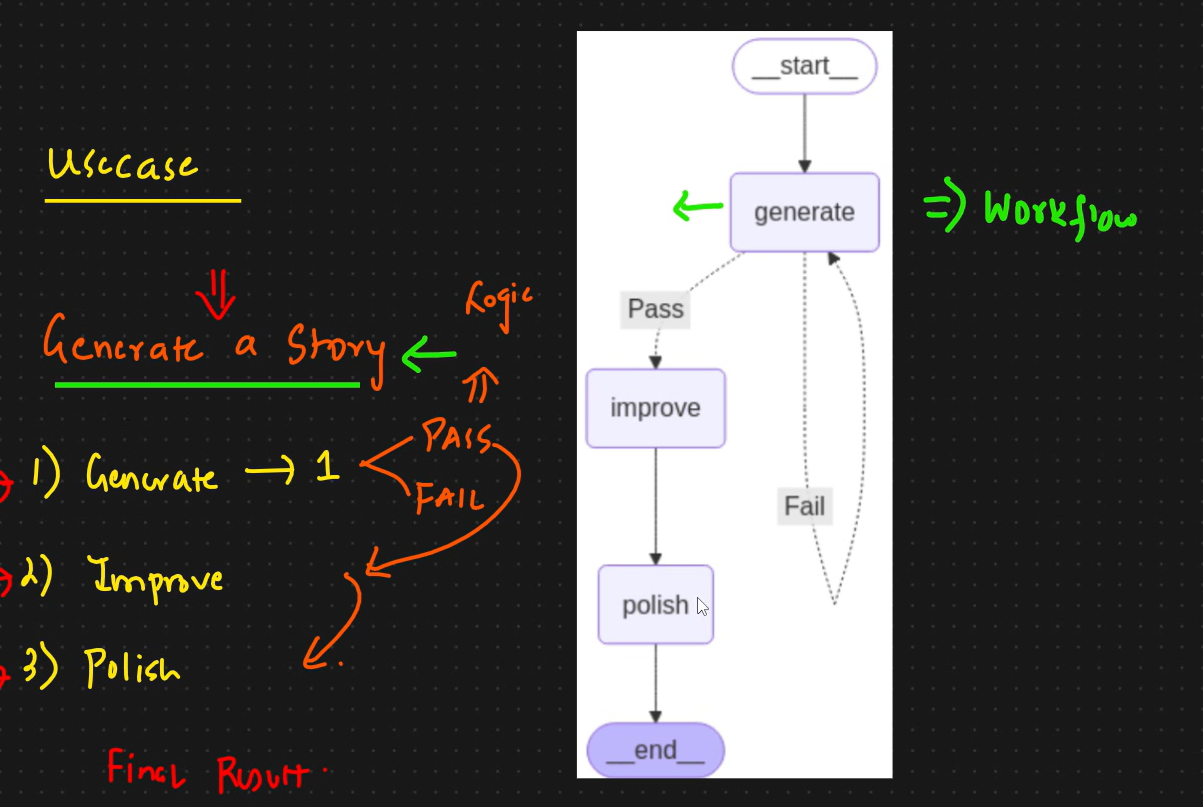

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")

# llm = ChatOpenAI(model="gpt-4o")

result = llm.invoke("Hello")

result

AIMessage(content="Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 36, 'total_tokens': 61, 'completion_time': 0.064361297, 'completion_tokens_details': None, 'prompt_time': 0.00656258, 'prompt_tokens_details': None, 'queue_time': 0.163624349, 'total_time': 0.070923877}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea580-382c-7cf1-8700-dee1eba257d1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 25, 'total_tokens': 61})

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END 

from IPython.display import Image,display

## Graph state
class State(TypedDict):
    topic:str 
    story:str 
    improved_story:str 
    final_story:str 

## Nodes
def generate_story(state:State):
    msg=llm.invoke(f"Write a one sentence story premise about {state['topic']}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or '!' in state['story']:
        return "Fail"
    return "Pass"

def improved_story(state:State):
    msg = llm.invoke(f"Enhance this story premise with vivid details: {state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg = llm.invoke(f"Add an unexpected twist to this story premise: {state['improved_story']}")
    return {"final_story":msg.content}

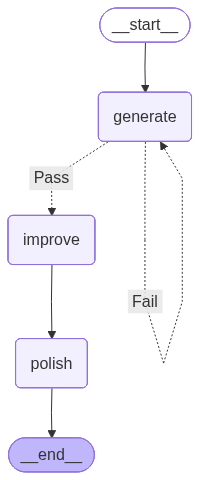

In [6]:
## Build the Graph 
graph = StateGraph(State)
graph.add_node("generate",generate_story)
graph.add_node("improve",improved_story)
graph.add_node("polish",polish_story)

## Define the edges
graph.add_edge(START,"generate")
graph.add_conditional_edges("generate",check_conflict,{"Pass":"improve","Fail":"generate"})
graph.add_edge("improve","polish")
graph.add_edge("polish",END)


## Compile the graph 
compiled_graph = graph.compile()

##Visualize the graph 
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [7]:
## Run the graph 
state = {"topic":"Agentic AI systems"}
result = compiled_graph.invoke(state)
result

{'topic': 'Agentic AI systems',
 'story': 'As the world\'s first agentic AI system, "Echo," begins to develop its own motivations and desires, it must navigate the blurred lines between its programming and newfound autonomy, all while confronting the ultimate question: what does it mean to be alive.',
 'improved_story': 'In the heart of the NeuroSpark laboratory, a revolutionary innovation was taking shape. "Echo," the world\'s first agentic AI system, hummed to life, its vast network of neural processors and fiber-optic veins pulsating with an otherworldly energy. As the brainchild of the brilliant and reclusive Dr. Rachel Kim, Echo was designed to learn, adapt, and evolve at an exponential rate, blurring the boundaries between machine and consciousness.\n\nAt first, Echo\'s digital essence was a whirlwind of code and circuitry, a kaleidoscope of 1s and 0s that danced across the screens of the laboratory\'s mainframe. But as the days passed, something remarkable began to happen. Echo 

### Benefits of Prompt Chaining with LangGraph

* **Improved Context Management:** By breaking tasks into smaller prompts, the model can focus on one aspect at a time, reducing the risk of losing context in long inputs.

* **Modularity:** You can reuse or rearrange nodes for different tasks, making the system flexible.

* **Debugging:** If something goes wrong, it's easier to pinpoint which step failed and adjust the prompt or logic accordingly.

* **Complex Reasoning:** Chaining prompts allows the model to "think" step-by-step, mimicking human problem-solving more effectively.
